01_data_preparation

02_feature_extraction_and_ml_traning

03_acoustic_DL

04_linguistic_DL

05_image_DL

# Check CPU/GPU/Memory

In [ ]:
# In order to use a GPU with the notebook, select the Runtime > Change runtime type menu and then set the hardware accelerator
gpu_info = !nvidia-smi
gpu_info = '\n'.join(gpu_info)
if gpu_info.find('failed') >= 0:
  print('Not connected to a GPU')
else:
  print(gpu_info)

Sat Jun 20 03:08:35 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA L4                      Off |   00000000:00:03.0 Off |                    0 |
| N/A   39C    P8             12W /   72W |       0MiB /  23034MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
# If the execution result of running the code cell below is 'Not using a high-RAM runtime',
# then we can enable a high-RAM runtime via Runtime > Change runtime type in the menu.
# Then select High-RAM in the Runtime shape toggle button

import psutil

ram_gb = psutil.virtual_memory().total / 1e9
print('Your runtime has {:.1f} gigabytes of available RAM\n'.format(ram_gb))

if ram_gb < 20:
  print('Not using a high-RAM runtime')
else:
  print('You are using a high-RAM runtime!')

Your runtime has 56.9 gigabytes of available RAM

You are using a high-RAM runtime!


# Imports

In [3]:
!pip install google-cloud-storage pydub librosa matplotlib scikit-learn transformers torch captum evaluate


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 455.2/455.2 kB 29.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 8.4 MB/s eta 0:00:00


In [4]:
!pip install --upgrade datasets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 555.1/555.1 kB 40.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 48.7 MB/s eta 0:00:00
  Attempting uninstall: pyarrow
    Found existing installation: pyarrow 18.1.0
    Uninstalling pyarrow-18.1.0:
      Successfully uninstalled pyarrow-18.1.0
  Attempting uninstall: datasets
    Found existing installation: datasets 4.0.0
    Uninstalling datasets-4.0.0:
      Successfully uninstalled datasets-4.0.0


In [5]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split


# Configurations

In [ ]:
from google.colab import auth
auth.authenticate_user()

# To find the credentials automatically
from google.cloud import storage
client = storage.Client(project=GCP_PROJECT_ID) # GCP Project ID

import os
os.environ["HF_TOKEN"] = HFTOKEN # token from the config cell

In [ ]:
# Initialize GCP Storage
client = storage.Client()
bucket_name = VOICE_DATA_BUCKET_NAME # GCP Storage bucket name
bucket = client.get_bucket(bucket_name)
print(f"Bucket {bucket.name} successfully loaded.")

Bucket voicedata-bucket successfully loaded.


In [8]:

print(os.getcwd())

/content


In [9]:
# Configuration
AUDIO_DIR_ADD = "local_data/ADDReSS2021/processed_audio"
AUDIO_DIR_WLS = "local_data/WLS/processed_audio"
CATEGORIES = ['CN', 'AD']

# Ensure local directories exist for processing
os.makedirs("local_data/ADDReSS2021/processed_audio/", exist_ok=True)
os.makedirs("local_data/WLS/processed_audio/", exist_ok=True)
os.makedirs("local_data/processed/", exist_ok=True)

# Download the processed data from GCP

In [10]:
# Download the final ADDReSSo & WLS Transcripts CSVs
print("Downloading processed transcripts...")
bucket.blob("ADDReSS2021/processed/final_transcripts.csv").download_to_filename("local_data/processed/final_transcripts.csv")
bucket.blob("WLS/processed/final_transcripts.csv").download_to_filename("local_data/processed/wls_transcripts.csv")

# Load into pandas DataFrames
df = pd.read_csv("local_data/processed/final_transcripts.csv")
df_wls = pd.read_csv("local_data/processed/wls_transcripts.csv")

print(f"\nSuccess! Loaded {len(df)} ADDReSSo records and {len(df_wls)} WLS records ready for ML.")
display(df.head())


Success! Loaded 161 ADDReSSo records and 40 WLS records ready for ML.


,participant_id,audio_path,transcript,label,label_numeric
0,adrso054,local_data/processed_audio/adrso054_par.wav,I'm gonna keep burying the meal. I'm gonna hav...,AD,1
1,adrso007,local_data/processed_audio/adrso007_par.wav,Our mother standing by the sink kind of looks ...,CN,0
2,adrso128,local_data/processed_audio/adrso128_par.wav,"Um, Cookie John, and he's stepping on us, well...",AD,1
3,adrso309,local_data/processed_audio/adrso309_par.wav,"Mother is, um, drying the dishes, looking out ...",CN,0
4,adrso274,local_data/processed_audio/adrso274_par.wav,"Alright, the boy is taking a cookie out of the...",CN,0


# Clean Data

In [11]:
from datasets import Dataset

# 1. Load Data (Fixed the path to include 'processed')
df = pd.read_csv("local_data/processed/final_transcripts.csv")

# 2. Clean Data: Remove empty transcripts
df = df.dropna(subset=['transcript'])
df = df[df['transcript'].str.strip() != '']
df_wls = df_wls.dropna(subset=['transcript'])
df_wls = df_wls[df_wls['transcript'].str.strip() != '']

# 3. Map labels to numeric values for PyTorch (AD = 1, CN = 0)
# Applied to BOTH datasets consistently
label2id = {'CN': 0, 'AD': 1}
df['label_id'] = df['label'].map(label2id)
df_wls['label_id'] = df_wls['label'].map(label2id)

print(f"Cleaned ADDReSSo dataset size: {len(df)} records.")
print(f"Cleaned WLS dataset size: {len(df_wls)} records.")

Cleaned ADDReSSo dataset size: 161 records.
Cleaned WLS dataset size: 40 records.


In [12]:
print("\nADDReSSo class distribution:")
print(df['label'].value_counts().to_string())

print("\nWLS class distribution:")
print(df_wls['label'].value_counts().to_string())


ADDReSSo class distribution:
label
AD    87
CN    74

WLS class distribution:
label
CN    20
AD    20


# The Train/Test Split

In [13]:
# Train/Val/Test Split (70-15-15) for ADDReSSo
# By default, train_test_split has the parameter shuffle=True
from datasets import Dataset

# First split: 70% Train, 30% Temp
X_train_full, X_temp, y_train_full, y_temp = train_test_split(
    df['transcript'], df['label_id'],
    test_size=0.30,
    stratify=df['label_id'],
    random_state=42
)

# Second split: 15% Val, 15% Test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=42
)

# External WLS Set
X_wls, y_wls = df_wls['transcript'], df_wls['label_id']

print(f"ADDReSSo Train: {len(X_train_full)} | Val: {len(X_val)} | Test: {len(X_test)}")
print(f"WLS External: {len(X_wls)}")

# Convert to Hugging Face Dataset objects for efficient processing
train_dataset = Dataset.from_dict({'text': X_train_full.tolist(), 'label': y_train_full.tolist()})
val_dataset = Dataset.from_dict({'text': X_val.tolist(), 'label': y_val.tolist()})
test_dataset = Dataset.from_dict({'text': X_test.tolist(), 'label': y_test.tolist()})
wls_dataset = Dataset.from_dict({'text': X_wls.tolist(), 'label': y_wls.tolist()})

ADDReSSo Train: 112 | Val: 24 | Test: 25
WLS External: 40


# Linguistic / Textual Modality

In [14]:
import torch
from transformers import TrainingArguments, Trainer
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)

    # Calculate probabilities for the positive class (AD = 1)
    probs = torch.nn.functional.softmax(torch.tensor(logits), dim=-1)[:, 1].numpy()

    acc = accuracy_score(labels, predictions)
    f1 = f1_score(labels, predictions, average='binary')
    precision = precision_score(labels, predictions, average='binary')
    recall = recall_score(labels, predictions, average='binary')
    auc = roc_auc_score(labels, probs)

    return {
        "accuracy": acc,
        "f1": f1,
        "precision": precision,
        "recall": recall,
        "auc": auc
    }

## BERT for Sequence Classification

Pipeline: Transcript => ModernBERT => Classification Head => AD/CN



Using BERT allows the model to capture semantic stagnation and contextual loss without relying purely on word counts.

In [ ]:
from transformers import BertTokenizer, BertForSequenceClassification, TrainingArguments, Trainer
from transformers import EarlyStoppingCallback

# Initialize Tokenizer and Model
tokenizer_bert = BertTokenizer.from_pretrained('bert-base-uncased')
model_bert = BertForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=2)

# Tokenization Function
def tokenize_bert(batch):
    return tokenizer_bert(batch['text'], padding="max_length", truncation=True, max_length=512)

# 1. Apply tokenization to ALL datasets
train_data_bert = train_dataset.map(tokenize_bert, batched=True)
val_data_bert = val_dataset.map(tokenize_bert, batched=True)
test_data_bert = test_dataset.map(tokenize_bert, batched=True)
wls_data_bert = wls_dataset.map(tokenize_bert, batched=True)

# 2. Set PyTorch format for ALL datasets
cols = ['input_ids', 'attention_mask', 'label']
train_data_bert.set_format('torch', columns=cols)
val_data_bert.set_format('torch', columns=cols)
test_data_bert.set_format('torch', columns=cols)
wls_data_bert.set_format('torch', columns=cols)

# Define Training Arguments
training_args_bert = TrainingArguments(
    output_dir='./results_bert',
    eval_strategy="epoch",
    save_strategy="epoch",             # Added to save checkpoints
    load_best_model_at_end=True,       # Added to prevent keeping an overfitted model
    metric_for_best_model="accuracy",  # Track accuracy for the best model
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=40,
    weight_decay=0.1,
    logging_steps=10
)

# Initialize Trainer
trainer_bert = Trainer(
    model=model_bert,
    args=training_args_bert,
    train_dataset=train_data_bert,
    eval_dataset=val_data_bert,        # Uses validation set, protecting the test set
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=10)]
)

In [16]:
# Train and Evaluate
print("Training BERT...")
trainer_bert.train()


Training BERT...


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall,Auc
1,0.670705,0.632567,0.625000,0.709677,0.611111,0.846154,0.888112
2,0.667526,0.539490,0.833333,0.818182,1.000000,0.692308,0.930070
3,0.501217,0.342326,0.916667,0.928571,0.866667,1.000000,0.993007
4,0.439884,0.250898,0.958333,0.960000,1.000000,0.923077,0.972028
5,0.291759,0.235618,0.958333,0.960000,1.000000,0.923077,0.923077
6,0.178071,0.171370,0.916667,0.923077,0.923077,0.923077,0.993007
7,0.119126,0.247546,0.916667,0.928571,0.866667,1.000000,0.993007
8,0.043113,0.389712,0.833333,0.857143,0.800000,0.923077,0.972028
9,0.010974,0.572030,0.875000,0.888889,0.857143,0.923077,0.965035
10,0.003341,0.569312,0.875000,0.888889,0.857143,0.923077,0.965035


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.atte

TrainOutput(global_step=196, training_loss=0.20423006661692444, metrics={'train_runtime': 88.8011, 'train_samples_per_second': 50.45, 'train_steps_per_second': 6.306, 'total_flos': 412558134804480.0, 'train_loss': 0.20423006661692444, 'epoch': 14.0})

In [17]:
print("Evaluating BERT...")
trainer_bert.evaluate()

Evaluating BERT...


Training Loss,Validation Loss,Epoch,Accuracy,F1,Precision,Recall,Auc
0.001498,0.250945,14,0.958333,0.960000,1.000000,0.923077,0.965035


{'eval_loss': 0.2509450912475586,
 'eval_accuracy': 0.9583333333333334,
 'eval_f1': 0.96,
 'eval_precision': 1.0,
 'eval_recall': 0.9230769230769231,
 'eval_auc': 0.965034965034965}

# Evaluation Metrics & Plotting Setup

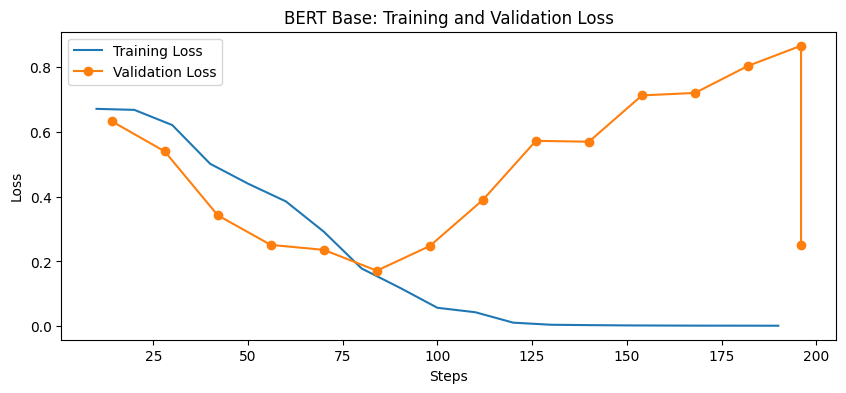


  Evaluating: BERT Base | Dataset: Training Set


Accuracy:    0.8929
Precision:   0.9623
Sensitivity: 0.8361
Specificity: 0.9608
F1-Score:    0.8947
ROC-AUC:     0.9846

              precision    recall  f1-score   support

      CN (0)       0.83      0.96      0.89        51
      AD (1)       0.96      0.84      0.89        61

    accuracy                           0.89       112
   macro avg       0.90      0.90      0.89       112
weighted avg       0.90      0.89      0.89       112



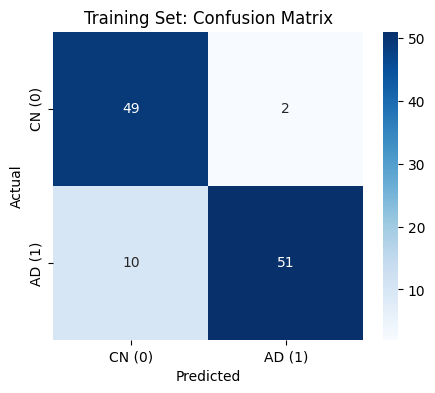


  Evaluating: BERT Base | Dataset: Validation Set


Accuracy:    0.9583
Precision:   1.0000
Sensitivity: 0.9231
Specificity: 1.0000
F1-Score:    0.9600
ROC-AUC:     0.9650

              precision    recall  f1-score   support

      CN (0)       0.92      1.00      0.96        11
      AD (1)       1.00      0.92      0.96        13

    accuracy                           0.96        24
   macro avg       0.96      0.96      0.96        24
weighted avg       0.96      0.96      0.96        24



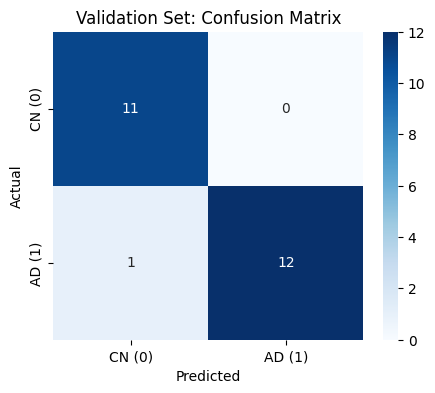


  Evaluating: BERT Base | Dataset: Testing Set


Accuracy:    0.6000
Precision:   0.6667
Sensitivity: 0.4615
Specificity: 0.7500
F1-Score:    0.5455
ROC-AUC:     0.6090

              precision    recall  f1-score   support

      CN (0)       0.56      0.75      0.64        12
      AD (1)       0.67      0.46      0.55        13

    accuracy                           0.60        25
   macro avg       0.61      0.61      0.59        25
weighted avg       0.62      0.60      0.59        25



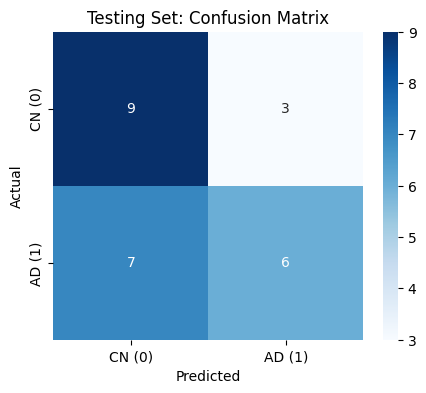


  Evaluating: BERT Base | Dataset: WLS External Set


Accuracy:    0.5000
Precision:   0.5000
Sensitivity: 0.1500
Specificity: 0.8500
F1-Score:    0.2308
ROC-AUC:     0.4800

              precision    recall  f1-score   support

      CN (0)       0.50      0.85      0.63        20
      AD (1)       0.50      0.15      0.23        20

    accuracy                           0.50        40
   macro avg       0.50      0.50      0.43        40
weighted avg       0.50      0.50      0.43        40



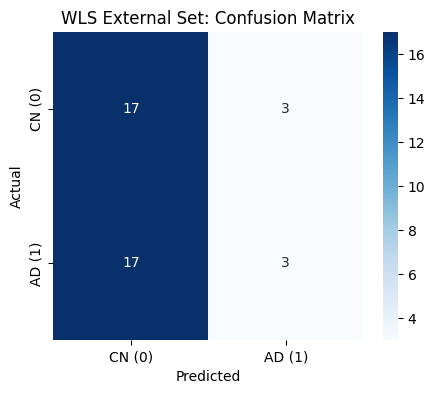

In [18]:
# ['CN (0)', 'AD (1)']
import torch
import seaborn as sns
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score, confusion_matrix, classification_report

# 1. Define Evaluation Metrics for the Trainer
def compute_metrics(eval_pred):
    logits, labels = eval_pred

    # Handle tuple output (in case the model returns hidden states alongside logits)
    if isinstance(logits, tuple):
        logits = logits[0]

    predictions = np.argmax(logits, axis=-1)

    # Calculate probabilities for the positive class (AD = 1)
    probs = torch.nn.functional.softmax(torch.tensor(logits), dim=-1)[:, 1].numpy()

    acc = accuracy_score(labels, predictions)
    f1 = f1_score(labels, predictions, average='binary')
    precision = precision_score(labels, predictions, average='binary')
    recall = recall_score(labels, predictions, average='binary')
    auc = roc_auc_score(labels, probs)

    return {
        "accuracy": acc,
        "f1": f1,
        "precision": precision,
        "recall": recall,
        "auc": auc
    }

# 2. Extract and Plot Loss Curves
def plot_loss_curves(trainer, model_name="BERT Base"):
    log_history = trainer.state.log_history

    # Extract loss data aligning steps appropriately
    train_steps = [x['step'] for x in log_history if 'loss' in x]
    train_loss = [x['loss'] for x in log_history if 'loss' in x]

    eval_steps = [x['step'] for x in log_history if 'eval_loss' in x]
    eval_loss = [x['eval_loss'] for x in log_history if 'eval_loss' in x]

    plt.figure(figsize=(10, 4))
    plt.plot(train_steps, train_loss, label='Training Loss')
    plt.plot(eval_steps, eval_loss, label='Validation Loss', marker='o')
    plt.title(f'{model_name}: Training and Validation Loss')
    plt.xlabel('Steps')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()

# 3. Comprehensive Clinical Evaluation Loop
def evaluate_bert_clinical(trainer, dataset, dataset_name):
    print(f"\n{'='*60}")
    print(f"  Evaluating: BERT Base | Dataset: {dataset_name}")
    print(f"{'='*60}")

    predictions = trainer.predict(dataset)
    logits = predictions.predictions

    if isinstance(logits, tuple):
        logits = logits[0]

    preds = np.argmax(logits, axis=-1)
    labels = predictions.label_ids

    # Probabilities for AUC
    probs = torch.nn.functional.softmax(torch.tensor(logits), dim=-1)[:, 1].numpy()

    # Core Metrics
    acc = accuracy_score(labels, preds)
    prec = precision_score(labels, preds)
    sens = recall_score(labels, preds)
    f1 = f1_score(labels, preds)

    # Specificity Calculation
    cm = confusion_matrix(labels, preds)
    tn, fp, fn, tp = cm.ravel()
    spec = tn / (tn + fp) if (tn + fp) > 0 else 0
    auc = roc_auc_score(labels, probs)

    print(f"Accuracy:    {acc:.4f}\nPrecision:   {prec:.4f}\nSensitivity: {sens:.4f}")
    print(f"Specificity: {spec:.4f}\nF1-Score:    {f1:.4f}\nROC-AUC:     {auc:.4f}\n")

    target_names = ['CN (0)', 'AD (1)']
    print(classification_report(labels, preds, target_names=target_names))

    # Confusion Matrix Plot
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=target_names, yticklabels=target_names)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title(f'{dataset_name}: Confusion Matrix')
    plt.show()

# 4. Execution Block
plot_loss_curves(trainer_bert)

eval_sets = [
    ("Training Set", train_data_bert),
    ("Validation Set", val_data_bert),
    ("Testing Set", test_data_bert),
    ("WLS External Set", wls_data_bert)
]

for name, dataset in eval_sets:
    evaluate_bert_clinical(trainer_bert, dataset, name)

# Feature Importance & Explainability (Saliency Maps)

In [ ]:
from captum.attr import LayerIntegratedGradients
from captum.attr import visualization as viz
from IPython.core.display import display, HTML
import torch

def plot_saliency_comparison(X_texts, y_labels, model, tokenizer):
    model.eval()
    model.zero_grad()

    # 1. Dynamically find one CN (0) and one AD (1) index from the test set
    idx_cn = y_labels[y_labels == 0].index[0]
    idx_ad = y_labels[y_labels == 1].index[0]

    # Package them into a list to iterate over
    samples = [
        (X_texts.loc[idx_cn], 0),
        (X_texts.loc[idx_ad], 1)
    ]

    # Identify the correct embedding layer dynamically
    if hasattr(model, 'bert'):
        ref_layer = model.bert.embeddings.word_embeddings
    elif hasattr(model, 'roberta'):
        ref_layer = model.roberta.embeddings.word_embeddings
    else:
        raise ValueError("Model architecture not supported for attribution.")

    # We will store the visualization records here
    records = []

    for text, true_label in samples:
        # Tokenize the input text
        inputs = tokenizer(text, return_tensors="pt", padding=True, truncation=True, max_length=512)
        input_ids = inputs["input_ids"].to(model.device)
        attention_mask = inputs["attention_mask"].to(model.device)

        # Wrapper for Captum forward pass
        def forward_func(inputs, attention_mask=None):
            return model(input_ids=inputs, attention_mask=attention_mask).logits

        lig = LayerIntegratedGradients(forward_func, ref_layer)

        # Compute attributions via Integrated Gradients
        attributions, delta = lig.attribute(
            inputs=input_ids,
            target=true_label,
            additional_forward_args=(attention_mask,),
            return_convergence_delta=True
        )

        # Summarize across the embedding dimension and normalize
        attributions_sum = attributions.sum(dim=-1).squeeze(0)
        attributions_sum = attributions_sum / torch.norm(attributions_sum)

        # Get the raw predicted probabilities
        logits = model(input_ids=input_ids, attention_mask=attention_mask).logits
        pred_prob = torch.softmax(logits, dim=-1)[0, true_label].item()
        pred_class = torch.argmax(logits).item()

        # Map input IDs back to string tokens for visualization
        tokens = tokenizer.convert_ids_to_tokens(input_ids[0].tolist())

        # Create the visual record and append it to our list
        vis_record = viz.VisualizationDataRecord(
            word_attributions=attributions_sum,
            pred_prob=pred_prob,
            pred_class=pred_class,
            true_class=true_label,
            attr_class=str(true_label),
            attr_score=attributions_sum.sum().item(),
            raw_input_ids=tokens,
            convergence_score=delta.item()
        )
        records.append(vis_record)

    # 3. Render both records in a single HTML table
    print("Saliency Comparison: Control Normal (Top) vs. Alzheimer's Disease (Bottom)")
    html_output = viz.visualize_text(records)
    # display(HTML(html_output.data))

# --- Example Usage ---
print("Analyzing BERT Saliency:")
plot_saliency_comparison(X_test, y_test, model_bert, tokenizer_bert)

Analyzing BERT Saliency:
Saliency Comparison: Control Normal (Top) vs. Alzheimer's Disease (Bottom)


In [20]:
# --- WLS External Dataset Saliency ---
print("Analyzing BERT Saliency: WLS External Dataset")
plot_saliency_comparison(X_wls, y_wls, model_bert, tokenizer_bert)

Analyzing BERT Saliency: WLS External Dataset
Saliency Comparison: Control Normal (Top) vs. Alzheimer's Disease (Bottom)
